In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import warnings

warnings.filterwarnings("ignore")
rng = np.random.default_rng(5141)

n_treated = 40
n_control = 60
TRUE_ATT = 5.0

rows = []
for i in range(n_treated):
    sid = f"T{i}"
    alpha = rng.normal(12, 2)  # store fixed effect (treated stores differ in levels)
    for year, post in [(2023, 0), (2024, 1)]:
        delta_year = 1.5 if post else 0.0  # common time trend / shock
        treat_effect = TRUE_ATT if post else 0.0
        eps = rng.normal(0, 1.2)
        Y = alpha + delta_year + treat_effect + eps
        rows.append({"store_id": sid, "year": year, "treated": 1, "post": post, "Y": Y})

for j in range(n_control):
    sid = f"C{j}"
    alpha = rng.normal(10, 2)
    for year, post in [(2023, 0), (2024, 1)]:
        delta_year = 1.5 if post else 0.0
        eps = rng.normal(0, 1.2)
        Y = alpha + delta_year + eps
        rows.append({"store_id": sid, "year": year, "treated": 0, "post": post, "Y": Y})

df_did = pd.DataFrame(rows)
print("Simulated store-year panel (2 periods)")
print(f"  True ATT on treated in post: +{TRUE_ATT}")
print(df_did.head(8))

Simulated store-year panel (2 periods)
  True ATT on treated in post: +5.0
  store_id  year  treated  post          Y
0       T0  2023        1     0   9.473839
1       T0  2024        1     1  14.539162
2       T1  2023        1     0  12.093955
3       T1  2024        1     1  18.199726
4       T2  2023        1     0  15.489879
5       T2  2024        1     1  22.466538
6       T3  2023        1     0  11.032999
7       T3  2024        1     1  17.111704


In [2]:
df_means = df_did.groupby(['treated', 'post'])['Y'].mean().reset_index()

mean_treated_post = df_means[(df_means['treated'] == 1) & (df_means['post'] == 1)]['Y'].values[0]
mean_treated_pre = df_means[(df_means['treated'] == 1) & (df_means['post'] == 0)]['Y'].values[0]
mean_control_post = df_means[(df_means['treated'] == 0) & (df_means['post'] == 1)]['Y'].values[0]
mean_control_pre = df_means[(df_means['treated'] == 0) & (df_means['post'] == 0)]['Y'].values[0]

did_estimate = (mean_treated_post - mean_treated_pre) - (mean_control_post - mean_control_pre)

print("Cell Means:")
print(f"  Treated Pre  : {mean_treated_pre:.4f}")
print(f"  Treated Post : {mean_treated_post:.4f}")
print(f"  Control Pre  : {mean_control_pre:.4f}")
print(f"  Control Post : {mean_control_post:.4f}")
print("\nManual DID Estimate:")
print(f"  ({mean_treated_post:.4f} - {mean_treated_pre:.4f}) - ({mean_control_post:.4f} - {mean_control_pre:.4f}) = {did_estimate:.4f}")


Cell Means:
  Treated Pre  : 11.6171
  Treated Post : 18.5722
  Control Pre  : 9.5338
  Control Post : 11.0095

Manual DID Estimate:
  (18.5722 - 11.6171) - (11.0095 - 9.5338) = 5.4794


In [5]:
# Create the interaction term
df_did['treated_x_post'] = df_did['treated'] * df_did['post']

# Define the dependent and independent variables
y = df_did['Y']
X = df_did[['treated', 'post', 'treated_x_post']]
X = sm.add_constant(X)  # Add intercept

# Fit the OLS model
model = sm.OLS(y, X).fit()

# Extract the coefficient for the interaction term
beta_interaction = model.params['treated_x_post']

print(model.summary())
print("\n" + "-"*50)
print(f"Regression Interaction Beta : {beta_interaction:.4f}")
print(f"Manual DID Estimate         : {did_estimate:.4f}")

if np.isclose(beta_interaction, did_estimate):
    print("\nThe regression coefficient matches the manual DID calculation.")
else:
    print("\nWarning: The estimates do not match.")


                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.654
Model:                            OLS   Adj. R-squared:                  0.649
Method:                 Least Squares   F-statistic:                     123.5
Date:                Thu, 09 Apr 2026   Prob (F-statistic):           6.08e-45
Time:                        22:01:56   Log-Likelihood:                -457.57
No. Observations:                 200   AIC:                             923.1
Df Residuals:                     196   BIC:                             936.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              9.5338      0.311     30.

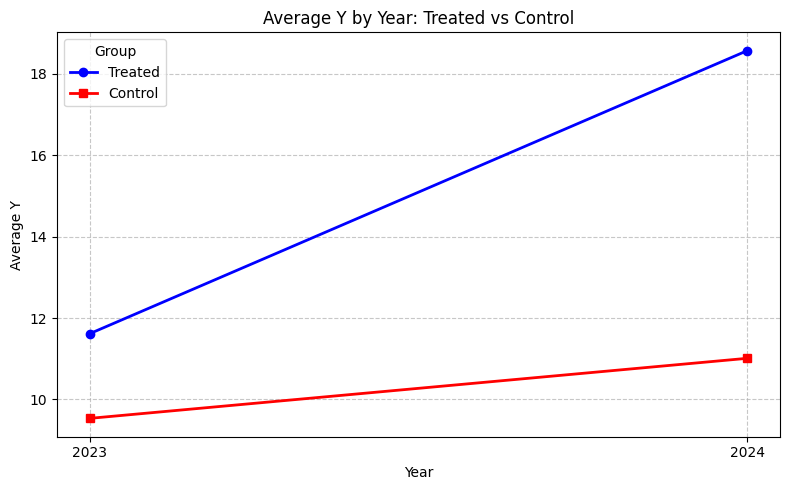

In [4]:
# Calculate the average Y by year and treatment group
df_plot = df_did.groupby(['year', 'treated'])['Y'].mean().unstack()

# Create the plot
plt.figure(figsize=(8, 5))
plt.plot(df_plot.index, df_plot[1], marker='o', label='Treated', color='blue', linewidth=2)
plt.plot(df_plot.index, df_plot[0], marker='s', label='Control', color='red', linewidth=2)

# Customize the plot with labels, title, and legend
plt.xticks([2023, 2024])
plt.xlabel('Year')
plt.ylabel('Average Y')
plt.title('Average Y by Year: Treated vs Control')
plt.legend(title='Group')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

The parallel-trends assumption in Difference-in-Differences requires that, in the absence of treatment, the average outcomes for the treated and control groups would evolve in parallel over time. With only one pre-treatment period (2023) in our current plot, we only observe a fixed baseline gap and cannot empirically verify this assumption. If we had multiple pre-treatment years, a violation would appear as the treated and control lines visibly converging or diverging *before* the treatment starts in 2024, rather than maintaining a constant vertical distance.